# CodeAlpha Internship

## Task 3: Data Visualization

### Project Title:
Amazon Sales Data Visualization

### Objective:
The objective of this project is to transform raw Amazon sales data into meaningful visualizations that reveal patterns, trends, and business insights for better decision-making.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
df = pd.read_csv("/content/amazon.csv")

df.head()



,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [7]:
print(df.shape)

df.columns

df.info()

df.describe(include='all')
df.isnull().sum()
df.duplicated().sum()

(1463, 16)
<class 'pandas.core.frame.DataFrame'>
Index: 1463 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1463 non-null   object
 1   product_name         1463 non-null   object
 2   category             1463 non-null   object
 3   discounted_price     1463 non-null   object
 4   actual_price         1463 non-null   object
 5   discount_percentage  1463 non-null   object
 6   rating               1463 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1463 non-null   object
 9   user_id              1463 non-null   object
 10  user_name            1463 non-null   object
 11  review_id            1463 non-null   object
 12  review_title         1463 non-null   object
 13  review_content       1463 non-null   object
 14  img_link             1463 non-null   object
 15  product_link         1463 non-null   object
dtype

np.int64(0)

In [10]:
# DATA CLEANING
#Convert prices to numeric
df['discounted_price'] = df['discounted_price'].str.replace('₹','', regex=False).str.replace(',','', regex=False).astype(float)

df['actual_price'] = df['actual_price'].str.replace('₹','', regex=False).str.replace(',','', regex=False).astype(float)

# Convert discount percentage
df['discount_percentage'] = df['discount_percentage'].str.replace('%','', regex=False).astype(float)

# Convert rating
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Convert rating count
df['rating_count'] = df['rating_count'].str.replace(',','', regex=False)
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce')

# Remove missing values
df.dropna(subset=['rating', 'rating_count'], inplace=True)

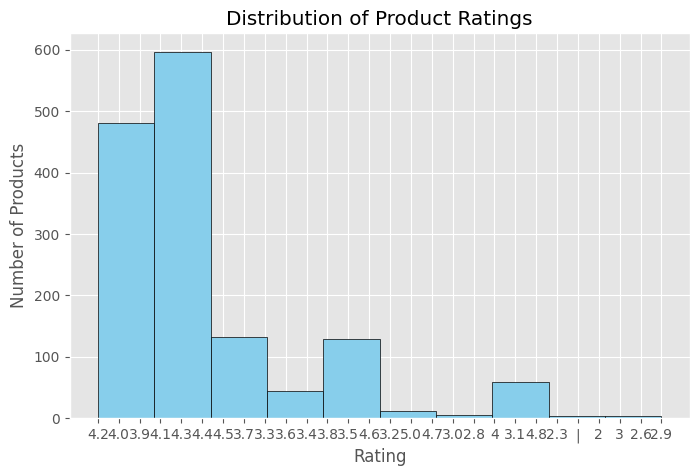

In [6]:
# FIRST VISUALIZATION - RATING DISTRIBUTION
plt.figure(figsize=(8,5))

plt.hist(df['rating'], bins=10, color='skyblue', edgecolor='black')

plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Products")

plt.show()

### Interpretation

Most products have ratings between 4.0 and 4.5, indicating that the majority of products receive positive customer feedback.

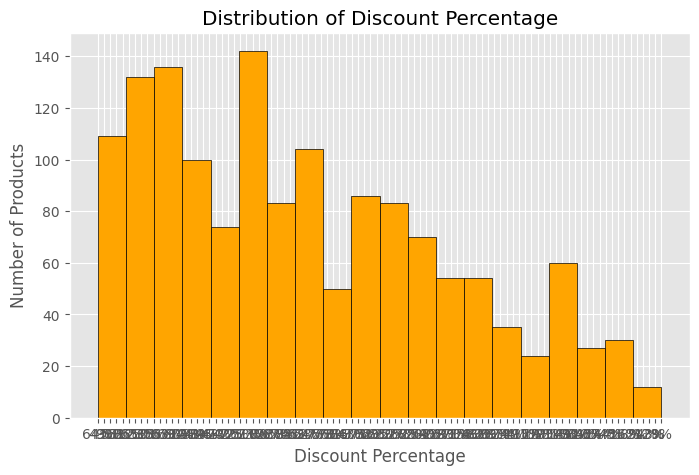

In [7]:
# DISCOUNT DISTRIBUTION
plt.figure(figsize=(8,5))

plt.hist(df['discount_percentage'],
         bins=20,
         color='orange',
         edgecolor='black')

plt.title("Distribution of Discount Percentage")
plt.xlabel("Discount Percentage")
plt.ylabel("Number of Products")

plt.show()

### Interpretation

The histogram shows how discount percentages are distributed across Amazon products. Most products fall within a moderate discount range, while only a few products offer very high discounts.

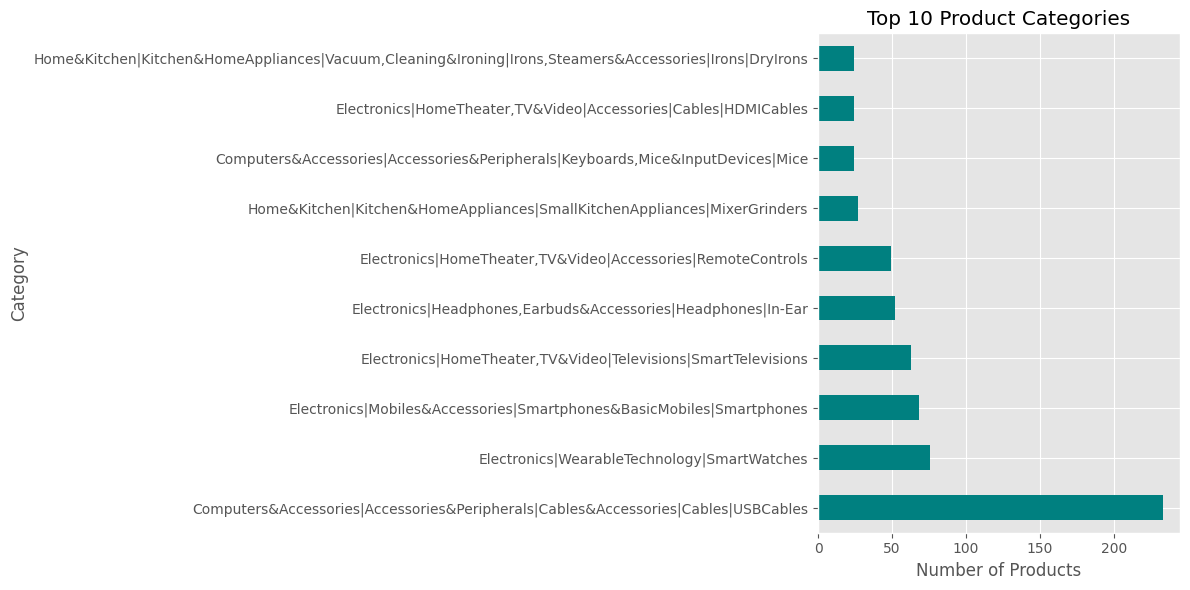

In [9]:
# TOP 10 PRODUCT CATEGORIES
top_categories = df['category'].value_counts().head(10)

plt.figure(figsize=(12,6))

top_categories.plot(kind='barh', color='teal')

plt.title("Top 10 Product Categories")
plt.xlabel("Number of Products")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

### Interpretation

This chart highlights the top 10 product categories with the highest number of products. It helps identify which categories dominate the Amazon marketplace.

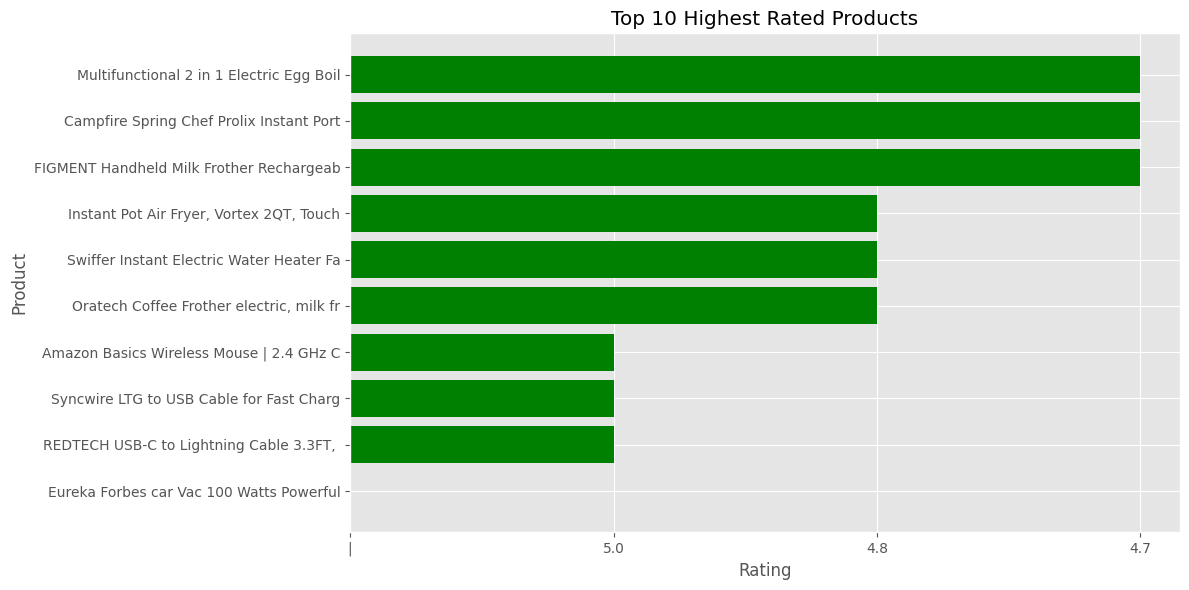

In [13]:
top_rated = df.sort_values(by='rating', ascending=False).head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_rated['product_name'].str[:40],   # માત્ર પહેલા 40 characters
    top_rated['rating'],
    color='green'
)

plt.title("Top 10 Highest Rated Products")
plt.xlabel("Rating")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

### Interpretation

The visualization shows the products with the highest customer ratings, indicating the best-performing products based on user feedback.

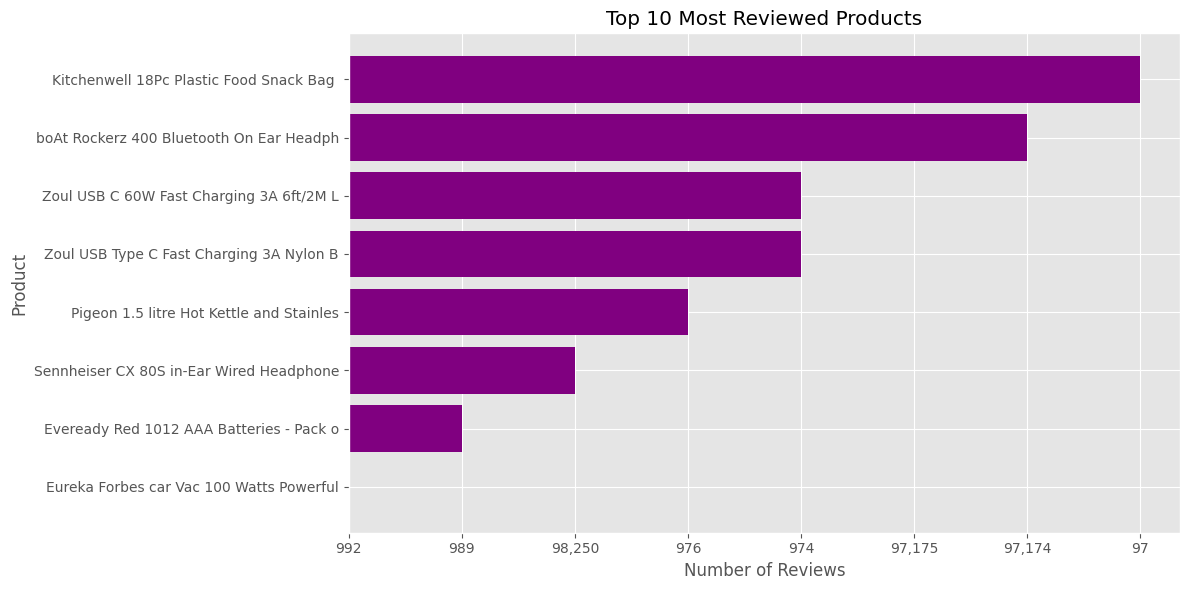

In [14]:
# TOP 10 MOST REVIWED PRODUCTS
top_reviewed = df.sort_values(by='rating_count', ascending=False).head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_reviewed['product_name'].str[:40],
    top_reviewed['rating_count'],
    color='purple'
)

plt.title("Top 10 Most Reviewed Products")
plt.xlabel("Number of Reviews")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

### Interpretation

This chart displays the top 10 most reviewed products on Amazon. Products with a higher number of reviews generally indicate greater customer engagement and popularity.

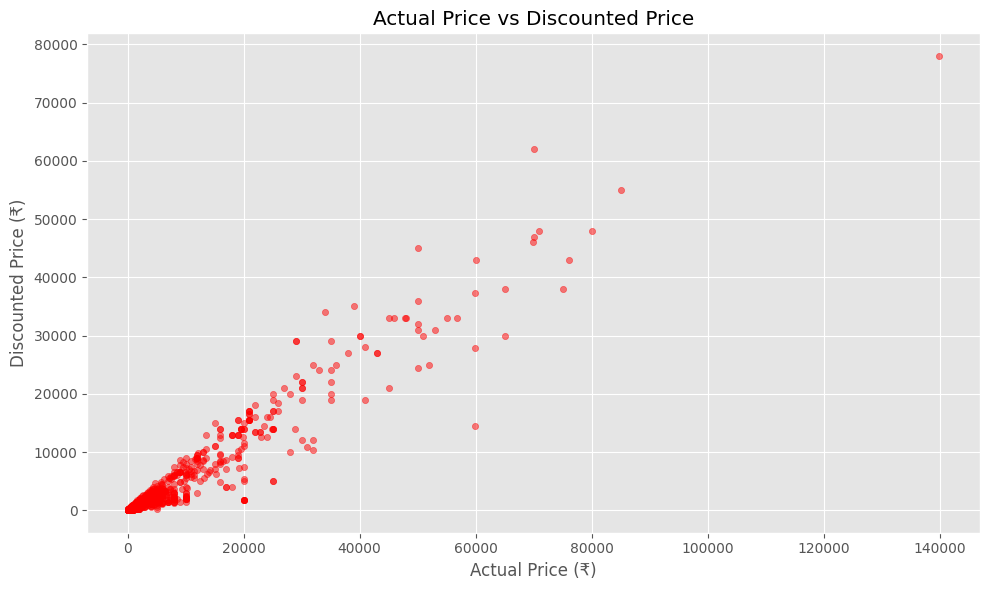

In [28]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['actual_price'],
    df['discounted_price'],
    alpha=0.5,
    s=20,
    color='red'
)

plt.title("Actual Price vs Discounted Price")
plt.xlabel("Actual Price (₹)")
plt.ylabel("Discounted Price (₹)")

plt.grid(True)
plt.tight_layout()

plt.show()

### Interpretation

The scatter plot compares actual prices with discounted prices. It shows that discounted prices increase as actual prices increase, indicating a positive relationship between the two variables.

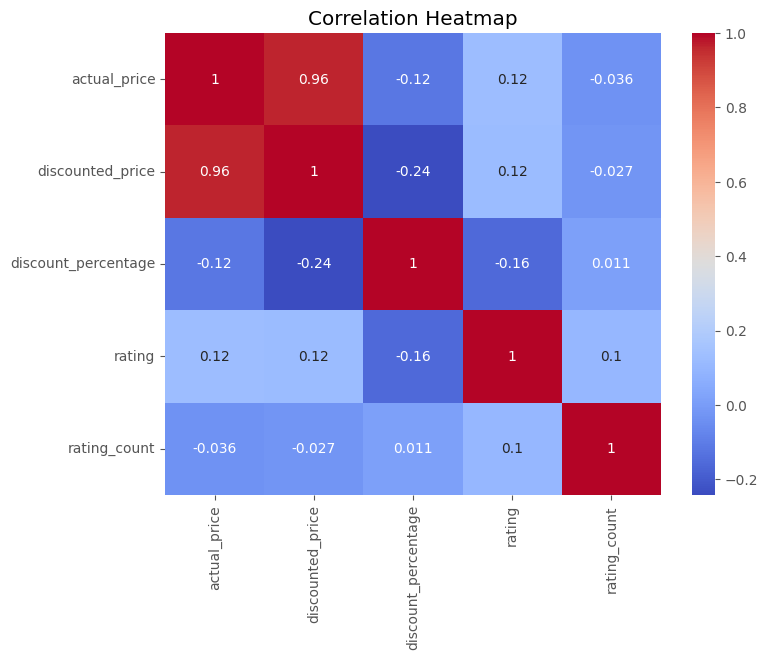

In [29]:
# CORRELATION HEATMAP
plt.figure(figsize=(8,6))

corr = df[['actual_price',
           'discounted_price',
           'discount_percentage',
           'rating',
           'rating_count']].corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

### Interpretation

The heatmap shows the correlation between numerical variables. Strong positive and negative relationships help understand how variables influence each other.

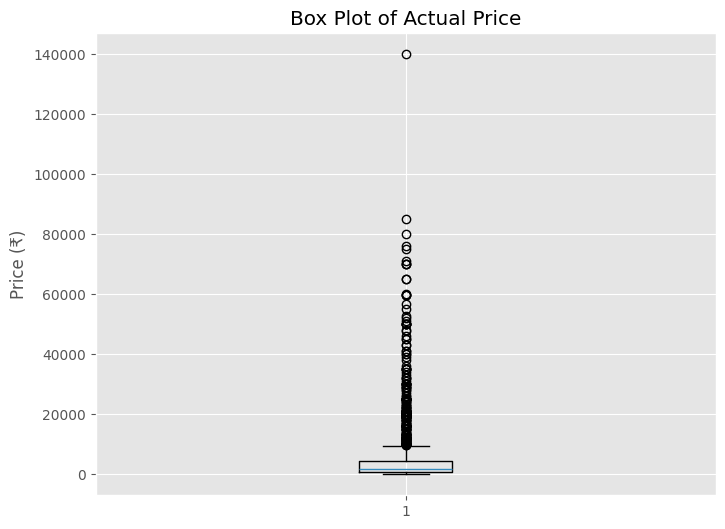

In [30]:
# BOXPLOT
plt.figure(figsize=(8,6))

plt.boxplot(df['actual_price'])

plt.title("Box Plot of Actual Price")
plt.ylabel("Price (₹)")

plt.show()

### Interpretation

The box plot identifies the distribution of actual product prices and highlights outliers. A few products have significantly higher prices than the majority.

## Conclusion

The visualizations clearly reveal trends in product ratings, pricing, discounts, and customer engagement. Most products have high ratings, while discounts vary across categories. Correlation analysis shows a strong relationship between actual and discounted prices. These visualizations support better business decisions and improve understanding of the Amazon sales dataset.